# Customer Segmentation — 04: Unsupervised Visualization (PCA & t-SNE)

**Series:** 01 EDA & RFM → 02 KMeans → 03 DBSCAN → 04 PCA & t-SNE (this notebook).

Two complementary lenses on the 6-dimensional RFM+ space:

- **PCA** — linear, global, interpretable: how much variance each direction carries
  and *what the directions mean* (loadings), plus a biplot.
- **t-SNE** — non-linear, local, interpretation-free: does the neighborhood structure
  contain shapes the linear view flattens? With a perplexity sensitivity scan, because
  a single t-SNE map is an anecdote.

Both views are colored with the labelings from notebooks 02 and 03 (recomputed here
with identical parameters and seeds, so the notebook is self-contained).

## 1. Setup, data, labels from notebooks 02–03

In [1]:
import os
import shutil
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42

DATA_PATH = "data/online_retail.csv"
KAGGLE_DATASET = "vijayuv/onlineretail"
MIRROR_URL = (
    "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/"
    "master/data/retail-data/all/online-retail-dataset.csv"
)


def fetch_data(path: str = DATA_PATH) -> str:
    """Download the dataset from Kaggle, falling back to a GitHub mirror."""
    if os.path.exists(path):
        print(f"Found cached file: {path}")
        return path
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        import kagglehub  # pip install kagglehub

        download_dir = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = [f for f in os.listdir(download_dir) if f.endswith(".csv")]
        shutil.copy(os.path.join(download_dir, csv_files[0]), path)
        print(f"Downloaded from Kaggle: {KAGGLE_DATASET}")
    except Exception as exc:
        print(f"Kaggle download failed ({exc!r}), using GitHub mirror.")
        urllib.request.urlretrieve(MIRROR_URL, path)
        print("Downloaded from mirror.")
    return path


def build_rfm(path: str = DATA_PATH) -> pd.DataFrame:
    """Cleaning rules and RFM+ construction — identical to notebook 01."""
    df = pd.read_csv(path, encoding="ISO-8859-1")
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
    canc = df.InvoiceNo.astype(str).str.startswith("C")
    d = df[~canc & df.CustomerID.notnull() & (df.Quantity > 0) & (df.UnitPrice > 0)].copy()
    d["Revenue"] = d.Quantity * d.UnitPrice
    snapshot = d.InvoiceDate.max() + pd.Timedelta(days=1)
    rfm = d.groupby("CustomerID").agg(
        recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
        frequency=("InvoiceNo", "nunique"),
        monetary=("Revenue", "sum"),
        tenure=("InvoiceDate", lambda s: (snapshot - s.min()).days),
        n_products=("StockCode", "nunique"),
    )
    rfm["avg_order_value"] = rfm.monetary / rfm.frequency
    return rfm


from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

rfm = build_rfm(fetch_data())
FEATURES = list(rfm.columns)
X = StandardScaler().fit_transform(np.log1p(rfm))

# Labelings selected in notebooks 02 and 03 (same parameters and seeds)
km_labels = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit_predict(X)
db_labels = DBSCAN(eps=0.7, min_samples=10).fit_predict(X)
print(f"{X.shape[0]:,} customers × {X.shape[1]} features | "
      f"KMeans k=3 | DBSCAN eps=0.7 ({np.mean(db_labels == -1):.1%} noise)")

Found cached file: data/online_retail.csv
4,338 customers × 6 features | KMeans k=3 | DBSCAN eps=0.7 (13.9% noise)


## 2. PCA — variance structure

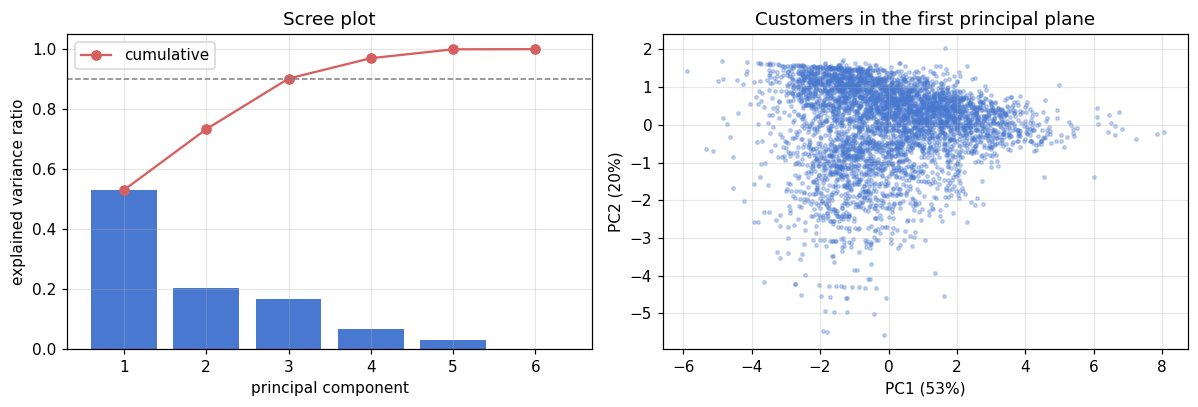

Explained variance: [0.531 0.203 0.169 0.068 0.03  0.   ] | cumulative: [0.531 0.733 0.902 0.97  1.    1.   ]


In [2]:
pca = PCA(random_state=RANDOM_STATE).fit(X)
evr = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(range(1, len(evr) + 1), evr, color="#4878CF")
axes[0].plot(range(1, len(evr) + 1), np.cumsum(evr), "-o", c="#D65F5F", label="cumulative")
axes[0].axhline(0.9, ls="--", c="gray", lw=1)
axes[0].set_xlabel("principal component")
axes[0].set_ylabel("explained variance ratio")
axes[0].set_title("Scree plot")
axes[0].legend()

Z = pca.transform(X)
axes[1].scatter(Z[:, 0], Z[:, 1], s=5, alpha=0.3, c="#4878CF")
axes[1].set_xlabel(f"PC1 ({evr[0]:.0%})")
axes[1].set_ylabel(f"PC2 ({evr[1]:.0%})")
axes[1].set_title("Customers in the first principal plane")
plt.tight_layout()
plt.show()
print("Explained variance:", np.round(evr, 3),
      "| cumulative:", np.round(np.cumsum(evr), 3))

## 3. PCA loadings — what the components mean

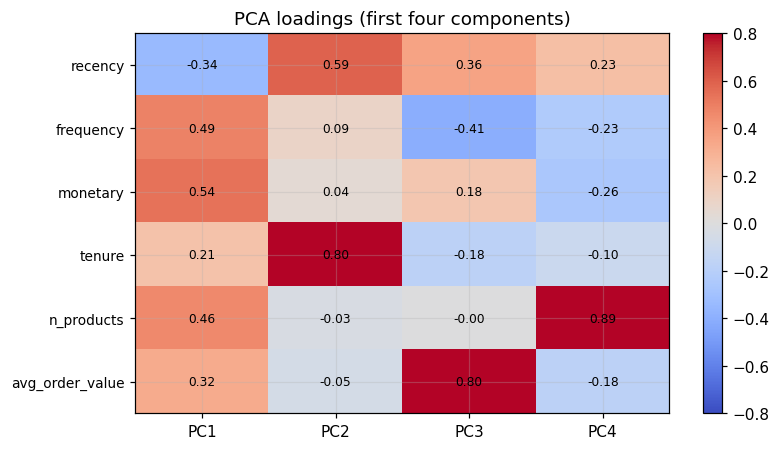

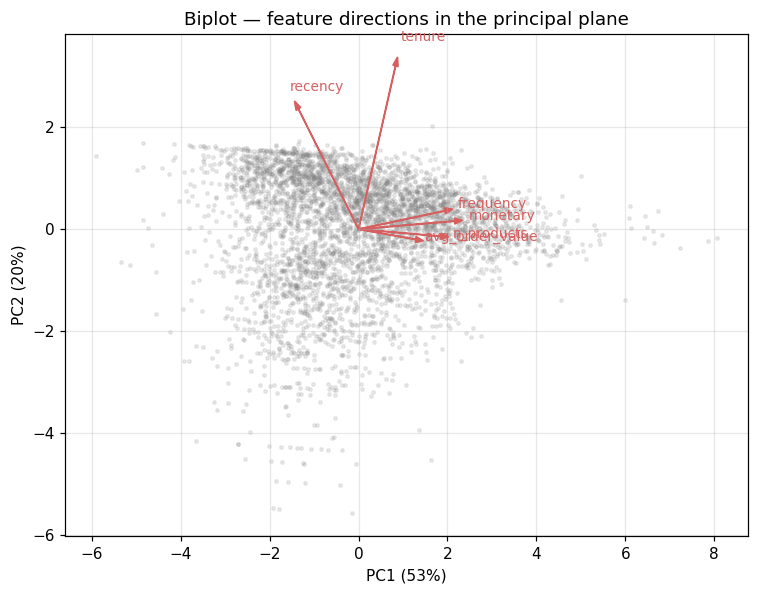

In [3]:
loadings = pd.DataFrame(pca.components_.T, index=FEATURES,
                        columns=[f"PC{i+1}" for i in range(len(FEATURES))])
fig, ax = plt.subplots(figsize=(7.5, 4.2))
im = ax.imshow(loadings.iloc[:, :4], cmap="coolwarm", vmin=-0.8, vmax=0.8, aspect="auto")
ax.set_xticks(range(4), loadings.columns[:4])
ax.set_yticks(range(len(FEATURES)), FEATURES, fontsize=9)
for i in range(len(FEATURES)):
    for j in range(4):
        ax.text(j, i, f"{loadings.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
ax.set_title("PCA loadings (first four components)")
plt.tight_layout()
plt.show()

# Biplot: customers + feature vectors in the PC1-PC2 plane
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(Z[:, 0], Z[:, 1], s=5, alpha=0.15, c="gray")
scale = 4.0
for feat in FEATURES:
    vx, vy = loadings.loc[feat, "PC1"] * scale, loadings.loc[feat, "PC2"] * scale
    ax.arrow(0, 0, vx, vy, color="#D65F5F", width=0.01, head_width=0.12)
    ax.text(vx * 1.15, vy * 1.15, feat, fontsize=9, c="#D65F5F")
ax.set_xlabel(f"PC1 ({evr[0]:.0%})")
ax.set_ylabel(f"PC2 ({evr[1]:.0%})")
ax.set_title("Biplot — feature directions in the principal plane")
plt.tight_layout()
plt.show()

**Component interpretation** (reading the loadings):

- **PC1 — customer value / engagement (53%).** `monetary` (0.54), `frequency` (0.49) and
  `n_products` (0.46) load together against `recency` (−0.34): one axis running from
  "lapsed one-timer" to "active, broad, high-spend regular". This is the engagement block
  the EDA correlation matrix predicted, compressed into a single direction.
- **PC2 — lifecycle age (20%).** `tenure` (0.80) *and* `recency` (0.59) load with the
  same sign — the long-registered-but-long-silent axis. High PC2 means "on the books for
  a year, last seen months ago"; low PC2 means recently acquired. Value-neutral: it
  separates old from new, not good from bad.
- **PC3 — basket style (17%).** `avg_order_value` (0.80) against `frequency` (−0.41):
  few-large-orders customers versus many-small-orders customers at comparable value.
- **PC4 — product breadth (7%).** Almost purely `n_products` (0.89) — assortment
  exploration net of spend.
- Two components carry 73% of the variance and three carry 90% — the 6-D space is
  effectively 3-dimensional, which is why the 2-D maps below are informative but not the
  whole story.

## 4. PCA maps colored by the clusterings

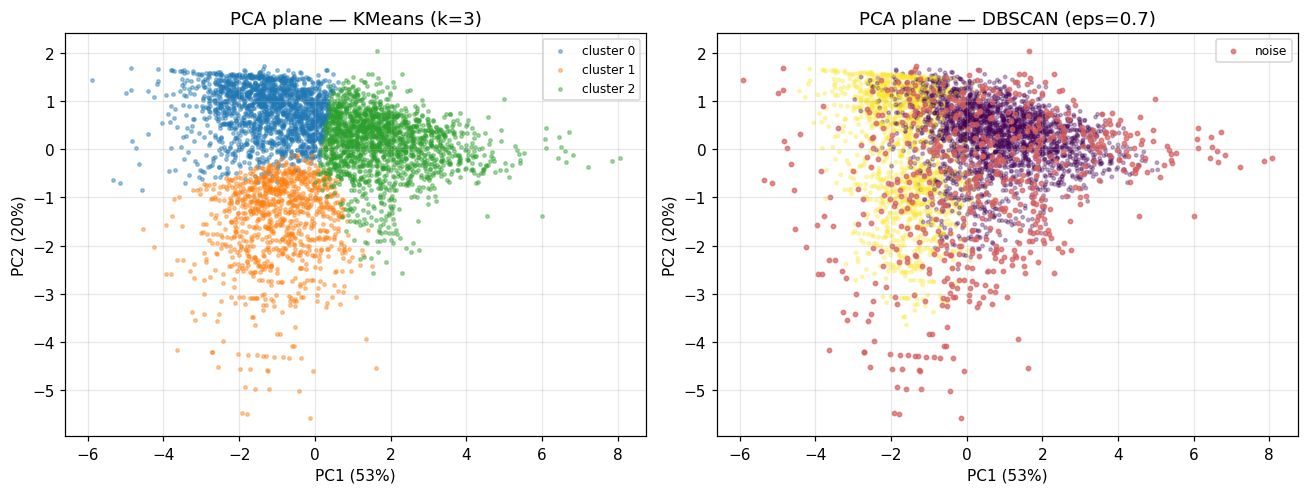

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for c in np.unique(km_labels):
    m = km_labels == c
    axes[0].scatter(Z[m, 0], Z[m, 1], s=5, alpha=0.4, label=f"cluster {c}")
axes[0].set_title("PCA plane — KMeans (k=3)")
axes[0].legend(fontsize=8)

noise = db_labels == -1
axes[1].scatter(Z[~noise, 0], Z[~noise, 1], s=5, alpha=0.3,
                c=db_labels[~noise], cmap="viridis")
axes[1].scatter(Z[noise, 0], Z[noise, 1], s=8, alpha=0.7, c="#D65F5F", label="noise")
axes[1].set_title("PCA plane — DBSCAN (eps=0.7)")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xlabel(f"PC1 ({evr[0]:.0%})")
    ax.set_ylabel(f"PC2 ({evr[1]:.0%})")
plt.tight_layout()
plt.show()

The KMeans partition slices the cloud along PC1 — the segments are, to first order,
*value tiers*. DBSCAN's noise rims the cloud from every side, confirming notebook 03's
reading of it as an extremeness detector.

## 5. t-SNE — the non-linear lens, with a perplexity scan

t-SNE preserves neighborhoods, not distances or densities — cluster sizes and gaps in
the map mean nothing, and each perplexity tells a different story. Three values,
spanning local to global emphasis:

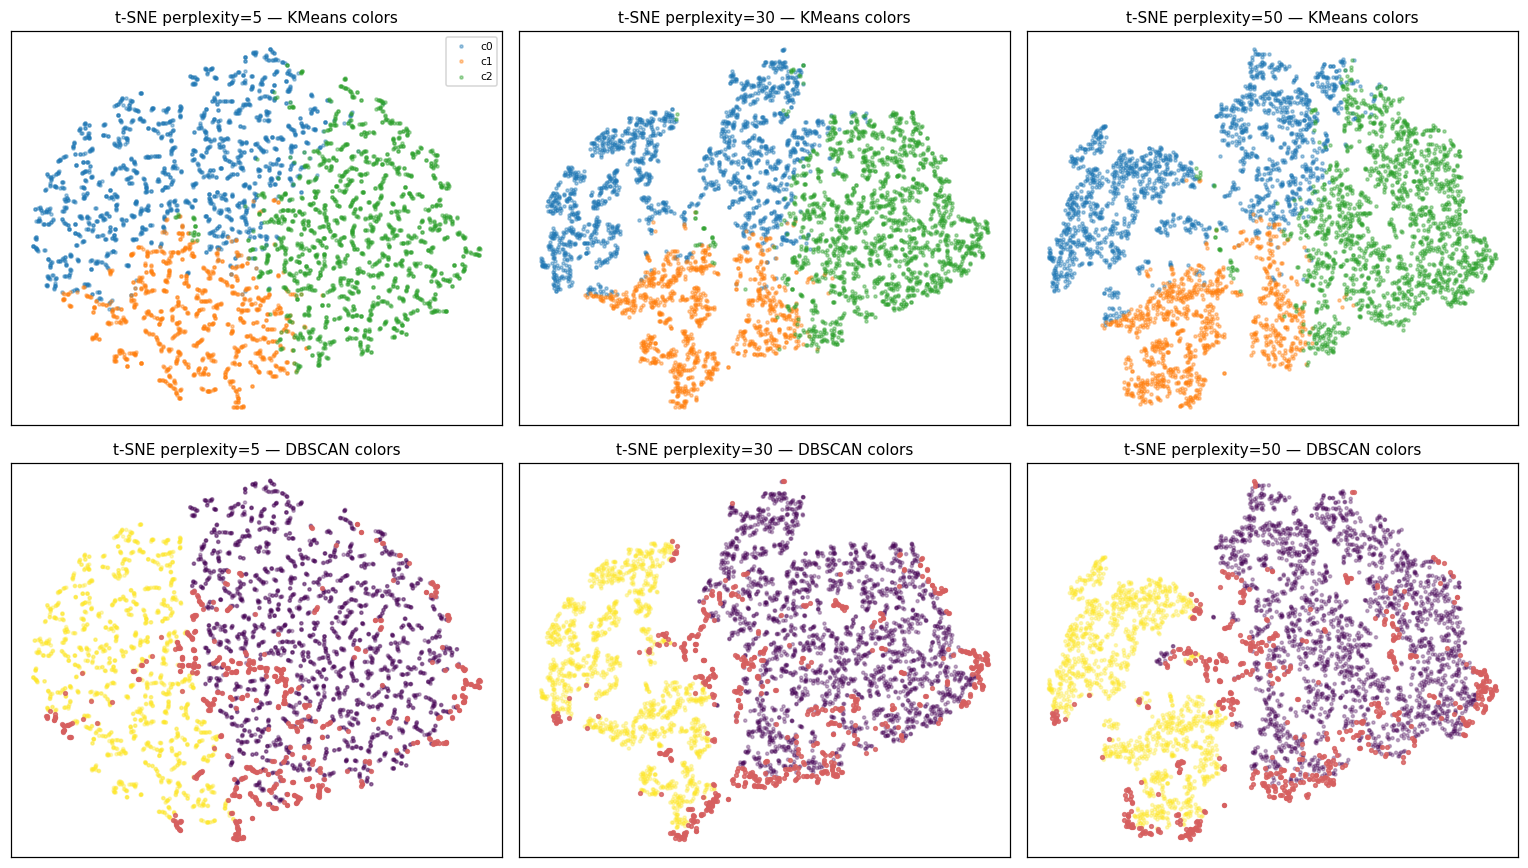

In [5]:
perplexities = [5, 30, 50]
embeddings = {}
for p in perplexities:
    embeddings[p] = TSNE(n_components=2, perplexity=p, random_state=RANDOM_STATE,
                         init="pca").fit_transform(X)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for j, p in enumerate(perplexities):
    E = embeddings[p]
    for c in np.unique(km_labels):
        m = km_labels == c
        axes[0, j].scatter(E[m, 0], E[m, 1], s=4, alpha=0.4, label=f"c{c}")
    axes[0, j].set_title(f"t-SNE perplexity={p} — KMeans colors", fontsize=10)

    noise = db_labels == -1
    axes[1, j].scatter(E[~noise, 0], E[~noise, 1], s=4, alpha=0.3,
                       c=db_labels[~noise], cmap="viridis")
    axes[1, j].scatter(E[noise, 0], E[noise, 1], s=6, alpha=0.8, c="#D65F5F")
    axes[1, j].set_title(f"t-SNE perplexity={p} — DBSCAN colors", fontsize=10)
axes[0, 0].legend(fontsize=7)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## 6. What the two lenses agree on

1. **No hidden islands.** Across all perplexities, t-SNE shows one connected body with
   density gradients — it does not reveal separated modes that PCA's linear view was
   hiding. The "RFM space is a continuum" conclusion now rests on three independent
   methods (EDA scatter, DBSCAN, t-SNE).
2. **The KMeans tiers are coherent regions**, not interleaved confetti: in every map
   the three colors occupy contiguous territory, meeting along the PC1 value axis —
   partitions of a continuum, but *stable, well-placed* partitions.
3. **DBSCAN noise sits on the high-value rim** in both projections — consistent with its
   role as the key-account list rather than a fourth segment.
4. **Practical note:** two linear components carry 73% of the variance and three carry
   90%, so PCA gives a serviceable but incomplete 2-D map here; t-SNE's contribution is
   the confirmation that the third dimension hides no separate structure, only the
   basket-style gradient PC3 already names.

**Series conclusion:** the deliverable is notebook 02's three actionable tiers plus
notebook 03's individually-handled extremes list — with notebooks 01 and 04 supplying
the evidence that this is the *right amount* of structure to claim from this data.